In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import math

In [2]:
# Configuration
random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Denormalization for visualization
def denormalize(tensor):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1).to(tensor.device)
    return tensor * std + mean

# Progressive training schedule
def get_progressive_weights(epoch, total_epochs):
    progress = epoch / total_epochs
    beta = min(1.0, progress * 2)  # Beta annealing
    perceptual_weight = min(0.2, progress * 0.4)  # Progressive perceptual loss
    return beta, perceptual_weight

# Enhanced data augmentation
def get_enhanced_cifar10_data():
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=5),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    
    train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
    
    return train_dataset, test_dataset

In [4]:
# Apply spectral normalization if requested
conv_layer = nn.Conv2d
conv_transpose_layer = nn.ConvTranspose2d
linear_layer = nn.Linear


In [ ]:
# Residual Block
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample=False):
        super().__init__()
        stride = 2 if downsample else 1
        self.conv1 = conv_layer(in_channels, out_channels, 3, stride=stride, padding=1)
        self.bn1 = nn.GroupNorm(8, out_channels)  # GroupNorm instead of BatchNorm
        self.conv2 = conv_layer(out_channels, out_channels, 3, stride=1, padding=1)
        self.bn2 = nn.GroupNorm(8, out_channels)
        
        self.downsample_layer = None
        if downsample or in_channels != out_channels:
            self.downsample_layer = nn.Sequential(
                conv_layer(in_channels, out_channels, 1, stride=stride),
                nn.GroupNorm(8, out_channels)
            )
        
    def forward(self, x):
        identity = x
        out = F.gelu(self.bn1(self.conv1(x)))  # GELU activation
        out = self.bn2(self.conv2(out))
        
        if self.downsample_layer:
            identity = self.downsample_layer(x)
        
        out += identity
        return F.gelu(out)


# Self-Attention Module
class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.in_channels = in_channels
        self.query = conv_layer(in_channels, in_channels // 8, 1)
        self.key = conv_layer(in_channels, in_channels // 8, 1)
        self.value = conv_layer(in_channels, in_channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))
        
    def forward(self, x):
        batch_size, channels, height, width = x.size()
        
        # Compute attention
        query = self.query(x).view(batch_size, -1, height * width).permute(0, 2, 1)
        key = self.key(x).view(batch_size, -1, height * width)
        value = self.value(x).view(batch_size, -1, height * width)
        
        attention = torch.bmm(query, key)
        attention = F.softmax(attention, dim=2)
        
        out = torch.bmm(value, attention.permute(0, 2, 1))
        out = out.view(batch_size, channels, height, width)
        
        return self.gamma * out + x


# Decoder blocks
class ResUpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, upsample=True):
        super().__init__()
        self.upsample = upsample
        
        if upsample:
            self.up = nn.ConvTranspose2d(in_channels, in_channels, 4, stride=2, padding=1)
        
        self.conv1 = conv_layer(in_channels, out_channels, 3, stride=1, padding=1)
        self.bn1 = nn.GroupNorm(8, out_channels)
        self.conv2 = conv_layer(out_channels, out_channels, 3, stride=1, padding=1)
        self.bn2 = nn.GroupNorm(8, out_channels)
        
        self.skip = None
        if in_channels != out_channels:
            self.skip = nn.Sequential(
                conv_layer(in_channels, out_channels, 1),
                nn.GroupNorm(8, out_channels)
            )
    
    def forward(self, x):
        if self.upsample:
            x = self.up(x)
        
        identity = x
        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        if self.skip:
            identity = self.skip(identity)
        
        return F.gelu(out + identity)
    
    
# Advanced VAE with multiple improvements
class AdvancedVAE(nn.Module):
    def __init__(self, latent_dim=512, use_spectral_norm=True, use_attention=True):
        super(AdvancedVAE, self).__init__()
        self.latent_dim = latent_dim
        self.use_attention = use_attention
        
        if use_spectral_norm:
            conv_layer = lambda *args, **kwargs: nn.utils.spectral_norm(nn.Conv2d(*args, **kwargs))
            conv_transpose_layer = lambda *args, **kwargs: nn.utils.spectral_norm(nn.ConvTranspose2d(*args, **kwargs))
            linear_layer = lambda *args, **kwargs: nn.utils.spectral_norm(nn.Linear(*args, **kwargs))
        
        # Enhanced Encoder with residual blocks
        self.encoder = nn.ModuleList([
            # Initial conv
            nn.Sequential(
                conv_layer(3, 64, 7, stride=1, padding=3),
                nn.GroupNorm(8, 64),
                nn.GELU()
            ),
            
            # Encoder blocks with residual connections
            ResBlock(64, 128, downsample=True),    # 32x32 -> 16x16
            ResBlock(128, 128),
            
            ResBlock(128, 256, downsample=True),   # 16x16 -> 8x8  
            ResBlock(256, 256),
            
            ResBlock(256, 512, downsample=True),   # 8x8 -> 4x4
            ResBlock(512, 512),
        ])
        
        # Self-attention in encoder
        if use_attention:
            self.enc_attention = SelfAttention(512)
        
        # Adaptive pooling to handle any input size
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        # Latent space with more sophisticated parameterization
        # self.fc_mu = linear_layer(512 * 4 * 4, latent_dim)
        # self.fc_var = linear_layer(512 * 4 * 4, latent_dim)
        # self.fc_decode = linear_layer(latent_dim, 512 * 4 * 4)
        
        # STL10: If final encoder feature = [512, 3, 3] → 4608
        self.fc_mu = nn.Linear(512 * 3 * 3, latent_dim)
        self.fc_var = nn.Linear(512 * 3 * 3, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 512 * 3 * 3)
        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, 512 * 3 * 3),
            nn.GELU()
        )
        
        # Enhanced Decoder with residual blocks
        self.decoder_input = nn.Sequential(
            linear_layer(latent_dim, 512 * 4 * 4),
            nn.GELU()
        )
        
        self.decoder = nn.ModuleList([
            ResUpBlock(512, 512, upsample=False),
            ResUpBlock(512, 256, upsample=True),   # 4x4 -> 8x8
            ResUpBlock(256, 256, upsample=False),
            ResUpBlock(256, 128, upsample=True),   # 8x8 -> 16x16  
            ResUpBlock(128, 128, upsample=False),
            ResUpBlock(128, 64, upsample=True),    # 16x16 -> 32x32
            ResUpBlock(64, 64, upsample=False),
        ])
        
        # Self-attention in decoder
        if use_attention:
            self.dec_attention = SelfAttention(128)
        
        # Final output layer with improved activation
        self.final_layer = nn.Sequential(
            conv_layer(64, 32, 3, padding=1),
            nn.GroupNorm(8, 32),
            nn.GELU(),
            conv_layer(32, 3, 3, padding=1),
            nn.Tanh()
        )
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def encode(self, x):
        # Forward through encoder blocks
        for i, block in enumerate(self.encoder):
            x = block(x)
        
        # Apply attention if enabled
        if self.use_attention:
            x = self.enc_attention(x)
        
        # Adaptive pooling and flatten
        x = self.adaptive_pool(x)
        x = torch.flatten(x, start_dim=1)
        
        # Get latent parameters
        mu = self.fc_mu(x)
        logvar = self.fc_var(x)
        return mu, logvar
    
    def decode(self, z):
        # Project to decoder input
        x = self.fc_decode(z)
        x = x.view(-1, 512, 4, 4)
        
        # Forward through decoder blocks
        for i, block in enumerate(self.decoder):
            x = block(x)
            # Apply attention at middle resolution
            if self.use_attention and i == 3:  # After 16x16 upsampling
                x = self.dec_attention(x)
        
        # Final output
        x = self.final_layer(x)
        return x
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


# Progressive loss with perceptual component.
class ProgressiveVAELoss(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.device = device
        
        # Load pretrained VGG for perceptual loss
        from torchvision.models import vgg16
        vgg = vgg16(pretrained=True).features[:16].to(device)
        vgg.eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg
        
        # Denormalization for VGG (expects ImageNet normalization)
        self.register_buffer('cifar_mean', torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1))
        self.register_buffer('cifar_std', torch.tensor([0.2023, 0.1994, 0.2010]).view(1, 3, 1, 1))
        self.register_buffer('imagenet_mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('imagenet_std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
    
    def preprocess_for_vgg(self, x):
        # Denormalize from CIFAR normalization
        x = x * self.cifar_std + self.cifar_mean
        # Normalize for ImageNet/VGG
        x = (x - self.imagenet_mean) / self.imagenet_std
        return x
    
    def forward(self, recon_x, x, mu, logvar, beta=1.0, perceptual_weight=0.1):
        batch_size = x.size(0)
        
        # Reconstruction loss (MSE)
        recon_loss = F.mse_loss(recon_x, x, reduction='sum')
        
        # Perceptual loss using VGG features
        if perceptual_weight > 0:
            x_vgg = self.preprocess_for_vgg(x)
            recon_vgg = self.preprocess_for_vgg(recon_x)
            
            x_features = self.vgg(x_vgg)
            recon_features = self.vgg(recon_vgg)
            perceptual_loss = F.mse_loss(recon_features, x_features, reduction='sum')
        else:
            perceptual_loss = 0
        
        # KL divergence with free bits
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        free_bits = 0.5  # Minimum KL per dimension
        kl_loss = torch.max(kl_loss, torch.tensor(free_bits * mu.size(1) * batch_size).to(x.device))
        
        # Total loss
        total_loss = recon_loss + perceptual_weight * perceptual_loss + beta * kl_loss
        
        return total_loss, recon_loss, perceptual_loss, kl_loss


In [6]:
model = AdvancedVAE(latent_dim=512, use_spectral_norm=True, use_attention=True).to(device)
print(model)

AdvancedVAE(
  (encoder): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (2): GELU(approximate='none')
    )
    (1): ResBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (bn1): GroupNorm(8, 128, eps=1e-05, affine=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): GroupNorm(8, 128, eps=1e-05, affine=True)
      (downsample_layer): Sequential(
        (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2))
        (1): GroupNorm(8, 128, eps=1e-05, affine=True)
      )
    )
    (2): ResBlock(
      (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): GroupNorm(8, 128, eps=1e-05, affine=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): GroupNorm(8, 128, eps=1e-05, affine=True)
    )
    (

In [ ]:
# Enhanced training setup
from pyparsing import C


def setup_training(fraction=1.0):
    # Get data with augmentation
    train_dataset_full, test_dataset_full = get_enhanced_cifar10_data()
    
    # Use larger subset for better results
    subset_size = int(len(train_dataset_full) * fraction)
    train_indices = np.random.choice(len(train_dataset_full), subset_size, replace=False)
    test_indices = np.random.choice(len(test_dataset_full), min(2000, len(test_dataset_full)), replace=False)
    
    train_dataset = Subset(train_dataset_full, train_indices)
    test_dataset = Subset(test_dataset_full, test_indices)

    # Compute mean and norm of the train_dataset
    loader = DataLoader(train_dataset, batch_size=256, shuffle=False, num_workers=4)
    mean = 0.0
    norm = 0.0
    total = 0
    for data, _ in loader:
        B,C,H,W = data.size()
        data = data.view(B, C, -1)  # Flatten spatial dimensions
        mean += data.mean(2).sum(0)
        norm += data.std(2).sum(0)
        total += B
    mean /= total
    norm /= total
    print(f"Mean: {mean}")
    print(f"Std: {norm}")
    
    # Larger batch size for better gradient estimates
    batch_size = 64  # Adjust based on GPU memoryz
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    print(f"Training on {len(train_dataset)} samples, Testing on {len(test_dataset)} samples")
    print(f"Total classes: {train_dataset_full.classes}")
    
    return train_loader, test_loader, train_dataset_full.classes


train_loader, test_loader, class_names = setup_training(fraction=1.0)

Files already downloaded and verified
Files already downloaded and verified
Mean: tensor([-0.0709, -0.0737, -0.0670])
Std: tensor([1.0337, 1.0345, 1.0249])
Training on 50000 samples, Testing on 2000 samples
Total classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
def show_reconstructions(model, test_loader, num_images=10, seed=42):
    print(f"Visualizing {num_images} random reconstructions...")

    np.random.seed(seed)
    torch.manual_seed(seed)

    model.eval()
    with torch.no_grad():
        data, _ = next(iter(test_loader))
        idx = np.random.choice(data.shape[0], num_images, replace=False)
        data = data[idx].to(device)
        recon, _, _ = model(data)
        
        data_denorm = denormalize(data).cpu()
        recon_denorm = denormalize(recon).cpu()
        
        fig, axes = plt.subplots(2, num_images, figsize=(16, 4))
        for i in range(num_images):
            # Original
            img_orig = data_denorm[i].permute(1, 2, 0).clamp(0, 1)
            axes[0, i].imshow(img_orig)
            axes[0, i].set_title('Original')
            axes[0, i].axis('off')
            
            # Reconstruction
            img_recon = recon_denorm[i].permute(1, 2, 0).clamp(0, 1)
            axes[1, i].imshow(img_recon)
            axes[1, i].set_title('Reconstructed')
            axes[1, i].axis('off')
        
        plt.tight_layout()
        plt.show()

In [ ]:
# Training function with advanced features
def train_advanced_vae():
    # Model
    print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    # Loss and optimizer
    criterion = ProgressiveVAELoss(device).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5, betas=(0.9, 0.999))
    
    # Advanced scheduling
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=2e-3,
        epochs=30,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        anneal_strategy='cos'
    )
    
    # Training parameters
    num_epochs = 30
    train_losses = []
    test_losses = []
    
    print("Starting advanced training...")
    
    for epoch in range(num_epochs):
        # Progressive weights
        beta, perceptual_weight = get_progressive_weights(epoch, num_epochs)
        
        # Training
        model.train()
        train_loss = 0
        train_recon_loss = 0
        
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            
            recon_batch, mu, logvar = model(data)
            loss, recon_loss, perceptual_loss, kl_loss = criterion(
                recon_batch, data, mu, logvar, beta, perceptual_weight
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            train_recon_loss += recon_loss.item()
        
        # Testing
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for data, _ in test_loader:
                data = data.to(device)
                recon_batch, mu, logvar = model(data)
                loss, _, _, _ = criterion(recon_batch, data, mu, logvar, beta, perceptual_weight)
                test_loss += loss.item()
        
        # Record losses
        avg_train_loss = train_loss / len(train_loader.dataset)
        avg_test_loss = test_loss / len(test_loader.dataset)
        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        
        # Print progress
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:2d}/{num_epochs} | '
              f'Train: {avg_train_loss:.4f} | Test: {avg_test_loss:.4f} | '
              f'Beta: {beta:.3f} | Perceptual: {perceptual_weight:.3f} | '
              f'LR: {current_lr:.6f}')
        
        # Show reconstructions
        if (epoch + 1) % 1 == 0:
            model.eval()
            show_reconstructions(model, test_loader, num_images=10, seed=random_seed)
    
    return train_losses, test_losses

In [64]:
train_losses, test_losses = train_advanced_vae()

# Plot final results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test')
plt.title('Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses[-20:], label='Train (last 20)')
plt.plot(test_losses[-20:], label='Test (last 20)')
plt.title('Final Convergence')
plt.xlabel('Epoch')

plt.grid(True)

plt.tight_layout()
plt.show()

Model parameters: 42,473,125


/home/nitin/miniconda3/envs/ml/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nitin/miniconda3/envs/ml/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Starting advanced training...


KeyboardInterrupt: 

In [ ]:
# Save the trained model
torch.save(model.state_dict(), "advanced_vae_cifar10.pth")

Visualizing 10 random reconstructions...


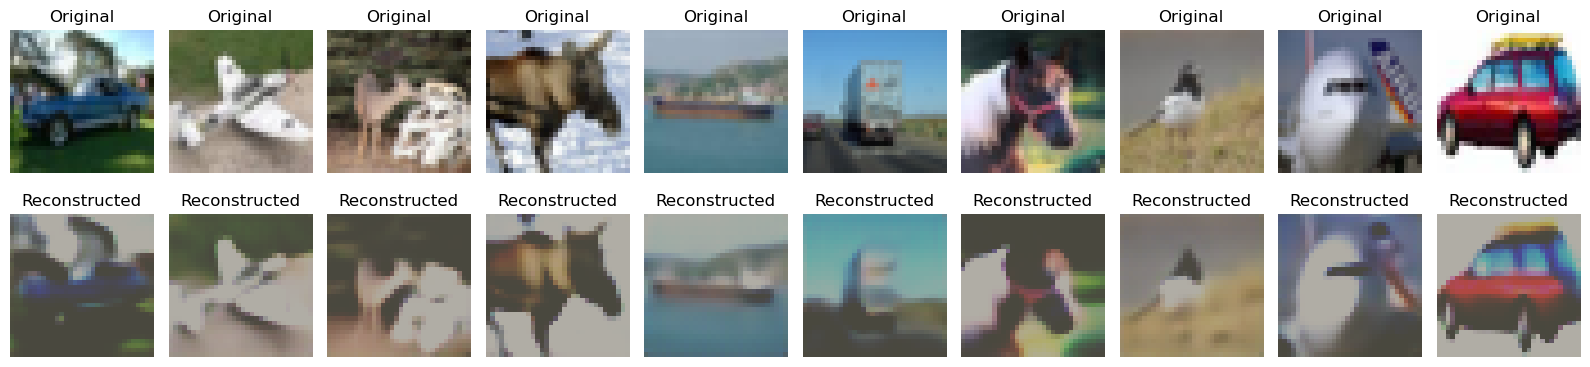

In [73]:
show_reconstructions(model, test_loader)